## Practical Exercise to Numerical Optimization

We consider the following unrestricted optimization problem (OP):
$$
\begin{aligned}
    f(x) := (x_1^2 - x_2)(x_1^2 - 3x_2)\rightarrow \min
\end{aligned}
$$
for $x \in \mathbb{R}^2$.

### Exercise 1
The corresponding one-dimensional restriction with respect to a direction $d \in \mathbb{R}^2$, $\|d\|_2=1$, is given by:
$$
\varphi_d(t) := f(x+td)
$$
Write a code which determines local minima of $\varphi_d$ with $x=d$ by solving the first-order necessary condition $\varphi_d'(t)=0$.


Determine $\varphi_d'$ and $\varphi_d''$ analytically. You should get the following result: The origin $t=-1$ is a local minimum of $\varphi_d$ for any $d$, i.e., $x+td=(0,0)$.

First we define the Peano Funktion, the dimensional restriction and their derivatives

In [102]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg as la

# ---------------------------------------------------------
# Mathematical Functions (Peano Surface)
# ---------------------------------------------------------

def peano_f(x):
    """Evaluates the Peano function."""
    return (x[0]**2 - x[1]) * (x[0]**2 - 3.0 * x[1])

def peano_jac(x):
    """Computes the Jacobian (Gradient) of the Peano function."""
    s1 = x[0]**2 - 3.0 * x[1]
    s2 = x[0]**2 - x[1]
    a1 = 2.0 * x[0] * (s1 + s2)
    a2 = -s1 - 3.0 * s2
    return np.array([a1, a2])

def peano_hessian(x):
    """Computes the Hessian matrix of the Peano function."""
    s1 = x[0]**2 - 3.0 * x[1]
    s2 = x[0]**2 - x[1]
    a = 2.0 * (s1 + s2) + 8.0 * x[0]**2
    b = 6.0
    c = -8.0 * x[0]
    return np.array([[a, c], [c, b]])

# ---------------------------------------------------------
# Directional Restriction Functions
# ---------------------------------------------------------

def dir_f(t, x, d):
    """Evaluates the function along direction d."""
    return peano_f(x+t * d)

def dir_prime(t, x, d):
    """First derivative with respect to t."""
    return peano_jac(x+t * d).dot(d)

def dir_hessian(t, x, d):
    """Second derivative with respect to t."""
    y = peano_hessian(x+ t * d).dot(d)
    return d.dot(y)

#Exercise  

Visualize the Peano Funktion and the 1d restrictions. What do you think will happen, if we apply a gradient search method to the 1d and 2d problem?

In [150]:
import numpy as np
import plotly.graph_objects as go


def plot_peano_with_lines_plotly():
    # 1. Create the Peano Surface
    x_range = np.linspace(-1.0, 1.0, 100)
    y_range = np.linspace(-0.2, 1.2, 100)
    X, Y = np.meshgrid(x_range, y_range)
    Z = (X**2 - Y) * (X**2 - 3.0 * Y)

    fig = go.Figure()

    # Plot surface
    fig.add_trace(go.Surface(
        x=X, y=Y, z=Z,
        colorscale='Viridis',
        opacity=0.6,
        name='Peano Surface',
        showscale=False
    ))

    t_vals = np.linspace(-2, 0, 150)

    # Define directions for 1D restrictions:
    directions = [
        (np.array([1, 0]), 'red', 'Direction (1,0)'),
        (np.array([0, 1]), 'blue', 'Direction (0,1)'),
        (np.array([2, -1]) / np.linalg.norm([2, -1]), 'black', 'Direction (2, -1)'),
    ]

    for d, color, label in directions:
        line_pts = np.array([d + t * d for t in t_vals])
        line_x = line_pts[:, 0]
        line_y = line_pts[:, 1]
        line_z = np.array([peano_f(p) for p in line_pts])

        # Plot the 3D line on the surface
        fig.add_trace(go.Scatter3d(
            x=line_x, y=line_y, z=line_z,
            mode='lines',
            line=dict(color=color, width=6),
            name=label
        ))

    # Layout configuration equivalent to view_init and labels
    fig.update_layout(
        title="Peano Surface with 1D Restrictions through Origin",
        scene=dict(
            xaxis_title="x1",
            yaxis_title="x2",
            zaxis_title="f(x)",
            camera=dict(
                eye=dict(x=1.2, y=-1.5, z=0.8) # Approximates elev=30, azim=-60
            )
        ),
        margin=dict(l=0, r=0, b=0, t=40),
        legend=dict(x=0, y=1, xanchor='left', yanchor='top')
    )

    fig.show()

plot_peano_with_lines_plotly()

#Exercise
Find the Minima of the 1d restrictions, using the descent method of you choice

Reminder: A descent method is given by
1.  Choose start value x0 ∈ Rn, k = 0.
2. If ||∇f (x_k )|| ≤ tol then STOP.
3. Determine decent direction d and step length $\alpha$ > 0 s.t. $f (x_k + \alpha d) < f(x_k )$.
4. Update $x_{k+1} := x_k + \alpha d$.
5. Increase k (k → k + 1) and Goto 2..

In [151]:
def solve_1d_descent(t0, x, d, alpha=1.0, tol=1e-6, max_iter=1000):
    """
    Solves the 1D restricted optimization problem phi_d(t) -> min!
    using a constant step size gradient descent.
    """
    t = t0
    for i in range(max_iter):
        # Evaluate the 1D derivative phi_d'(t)
        grad_t = dir_prime(t, x, d)

        # Check first-order necessary condition
        if abs(grad_t) < tol:
            print(f"Converged to t* = {t:.6f} in {i} iterations.")
            break

        # Descent step
        t = t - alpha * grad_t
        print("Step", i,"Residual", abs(grad_t),"min at t=",t)
    return t


x=np.array([0.0,1.0])
t0=0.1
min=solve_1d_descent(t0,x,x,alpha=0.1)


Step 0 Residual 6.6000000000000005 min at t= -0.5600000000000002
Step 1 Residual 2.639999999999999 min at t= -0.8240000000000001
Step 2 Residual 1.0559999999999996 min at t= -0.9296
Step 3 Residual 0.4224000000000001 min at t= -0.97184
Step 4 Residual 0.16895999999999978 min at t= -0.9887360000000001
Step 5 Residual 0.06758399999999964 min at t= -0.9954944
Step 6 Residual 0.02703359999999999 min at t= -0.99819776
Step 7 Residual 0.01081343999999973 min at t= -0.999279104
Step 8 Residual 0.004325376000000158 min at t= -0.9997116416
Step 9 Residual 0.001730150399999797 min at t= -0.99988465664
Step 10 Residual 0.0006920601599997855 min at t= -0.9999538626560001
Step 11 Residual 0.00027682406399964776 min at t= -0.9999815450624
Step 12 Residual 0.00011072962559999233 min at t= -0.99999261802496
Step 13 Residual 4.429185024013016e-05 min at t= -0.999997047209984
Step 14 Residual 1.7716740096318517e-05 min at t= -0.9999988188839936
Step 15 Residual 7.086696038660634e-06 min at t= -0.9999995

#Exercise

Solve the unconstrained 2d problem using a descent method. Try differnt step length strategies

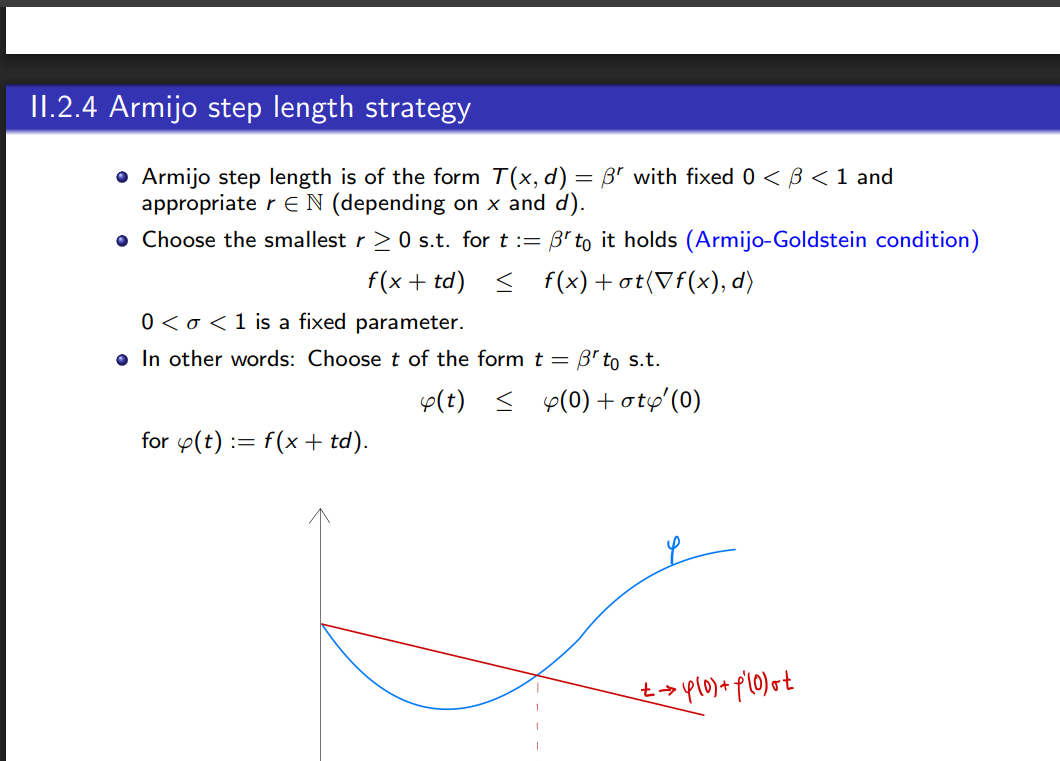

In [139]:
import numpy as np
import scipy.optimize as opt

# ---------------------------------------------------------
# Objective Functions & Gradients
# ---------------------------------------------------------

def f_test(x):
    """Strictly convex test function."""
    return 0.1 * x[0]**2 + x[1]**2

def grad_test(x):
    return np.array([0.2 * x[0], 2.0 * x[1]])


# ---------------------------------------------------------
# Step Size Strategies
# ---------------------------------------------------------

def step_constant(x, d, f_func, grad_func, alpha=0.2):
    """Constant step size."""
    return alpha

def step_armijo(x, d, f_func, grad_func, sigma=1e-4, beta=0.5):
    """Armijo rule for sufficient decrease."""
    alpha = 1.0
    f_val = f_func(x)
    dir_deriv = np.dot(grad_func(x), d)

    while f_func(x + alpha * d) > f_val + sigma * alpha * dir_deriv:
        alpha *= beta
        if alpha < 1e-10:
            break
    return alpha

def step_exact(x, d, f_func, grad_func):
    """Exact step size """
    res = opt.minimize_scalar(lambda alpha: f_func(x + alpha * d))
    return res.x

# ---------------------------------------------------------
# Gradient Descent
# ---------------------------------------------------------

def gradient_descent(x0, f_func, grad_func, step_strategy, tol=1e-5, max_iter=1000):
    x = np.array(x0, dtype=float)
    for k in range(max_iter):
        grad = grad_func(x)
        if np.linalg.norm(grad) < tol:
            break
        d = -grad
        alpha = step_strategy(x, d, f_func, grad_func)
        x = x + alpha * d
    return x, k

# ---------------------------------------------------------
# Exercise 3
# ---------------------------------------------------------

def exercise_3_test():
    print("--- Exercise 3: Unrestricted Optimization (Test Problem) ---")
    x0 = [5.0, 5.0]

    x_const, k_const = gradient_descent(x0, f_test, grad_test, step_constant)
    print(f"Constant Step  | Iter: {k_const:4d} | x*: {x_const}")

    x_armijo, k_armijo = gradient_descent(x0, f_test, grad_test, step_armijo)
    print(f"Armijo Step    | Iter: {k_armijo:4d} | x*: {x_armijo}")

    x_exact, k_exact = gradient_descent(x0, f_test, grad_test, step_exact)
    print(f"Exact Step     | Iter: {k_exact:4d} | x*: {x_exact}")

def exercise_3():
    print("--- Exercise 3")
    x0 = [0.0, 1.0]

    x_const, k_const = gradient_descent(x0, peano_f, peano_jac, step_constant)
    print(f"Constant Step  | Iter: {k_const:4d} | x*: {x_const}")

    x_armijo, k_armijo = gradient_descent(x0, peano_f, peano_jac, step_armijo)
    print(f"Armijo Step    | Iter: {k_armijo:4d} | x*: {x_armijo}")

    x_exact, k_exact = gradient_descent(x0, peano_f, peano_jac, step_exact)
    print(f"Exact Step     | Iter: {k_exact:4d} | x*: {x_exact}")


exercise_3()

--- Exercise 3
Constant Step  | Iter:    9 | x*: [ 0.00e+00 -5.12e-07]
Armijo Step    | Iter:   20 | x*: [0.00000000e+00 9.53674316e-07]
Exact Step     | Iter:    1 | x*: [0. 0.]


Does this mean we have a local minimum at the point (0,0)?

### Exercise 4: The Penalty Method for Restricted Optimization

Let $f: \mathbb{R}^2 \rightarrow \mathbb{R}$ be the Peano function from before
$$f(x) := (x_1^2 - x_2)(x_1^2 - 3x_2)$$

The restricted optimization problem we consider reads:

$$(ROP) \quad f(x^*) = \min\{f(x) : x \in X\}$$

with the admissible set $X := \{x \in \mathbb{R}^2 : g(x) \le 0\}$ and the constraint function:
$$g(x) := -x_1 + x_2 + c$$


Use the penalty method (with penalty parameter $\alpha > 0$) in order to consider inequality constraints.

1. Apply your algorithm to get solutions in dependence of $\alpha = 2^k$, for $k = 0, \dots, 4$.
2. You may use the solution for $\alpha = 2^k$ as the initial guess for the iteration for $\alpha = 2^{k+1}$ (warm-starting).
3. Use a simple gradient search $d := -\nabla f(x)$ and the step sizes from the previous exercise.

Do you obtain admissible solutions?

<>:26: SyntaxWarning:

invalid escape sequence '\l'

<>:26: SyntaxWarning:

invalid escape sequence '\l'

/tmp/ipython-input-659/2455317625.py:26: SyntaxWarning:

invalid escape sequence '\l'



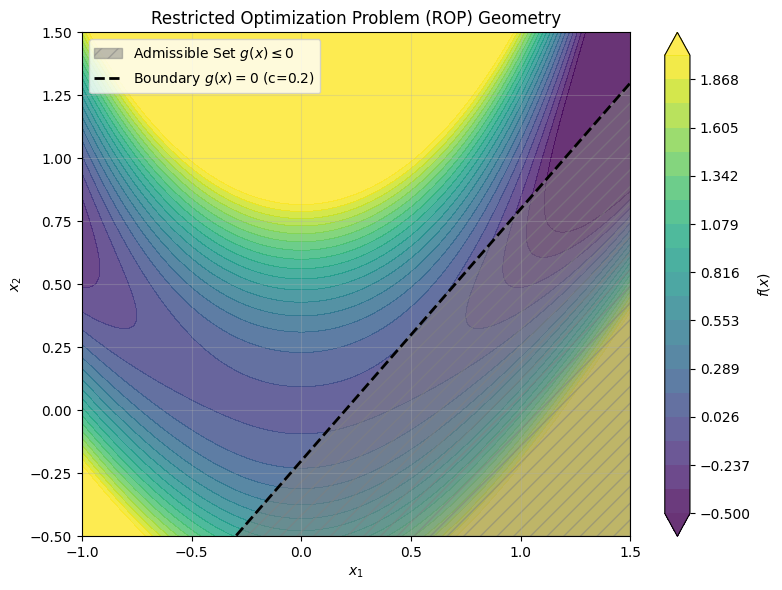

In [145]:


def plot_admissible_set(c=0.2):
    """
    Plots the Peano function contours and the admissible set X.
    """
    # Grid definition
    x1 = np.linspace(-1.0, 1.5, 400)
    x2 = np.linspace(-0.5, 1.5, 400)
    X1, X2 = np.meshgrid(x1, x2)

    # Peano function evaluation
    Z = (X1**2 - X2) * (X1**2 - 3.0 * X2)

    fig, ax = plt.subplots(figsize=(8, 6))

    # Contour plot of the objective function
    # Limiting the levels highlights the negative valley between the parabolas
    levels = np.linspace(-0.5, 2.0, 20)
    cp = ax.contourf(X1, X2, Z, levels=levels, cmap='viridis', extend='both', alpha=0.8)
    fig.colorbar(cp, ax=ax, label='$f(x)$')

    # Admissible set boundary: -x1 + x2 + c = 0 => x2 = x1 - c
    x2_boundary = x1 - c

    # Shade the admissible region (g(x) <= 0)
    ax.fill_between(x1, -0.5, x2_boundary, where=(x2_boundary >= -0.5),
                    color='gray', alpha=0.5, hatch='//', label=f'Admissible Set $g(x) \leq 0$')

    # Plot the constraint boundary line
    ax.plot(x1, x2_boundary, 'k--', linewidth=2, label=f'Boundary $g(x) = 0$ (c={c})')


    ax.set_xlim([-1.0, 1.5])
    ax.set_ylim([-0.5, 1.5])
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title('Restricted Optimization Problem (ROP) Geometry')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_admissible_set(c=0.2)

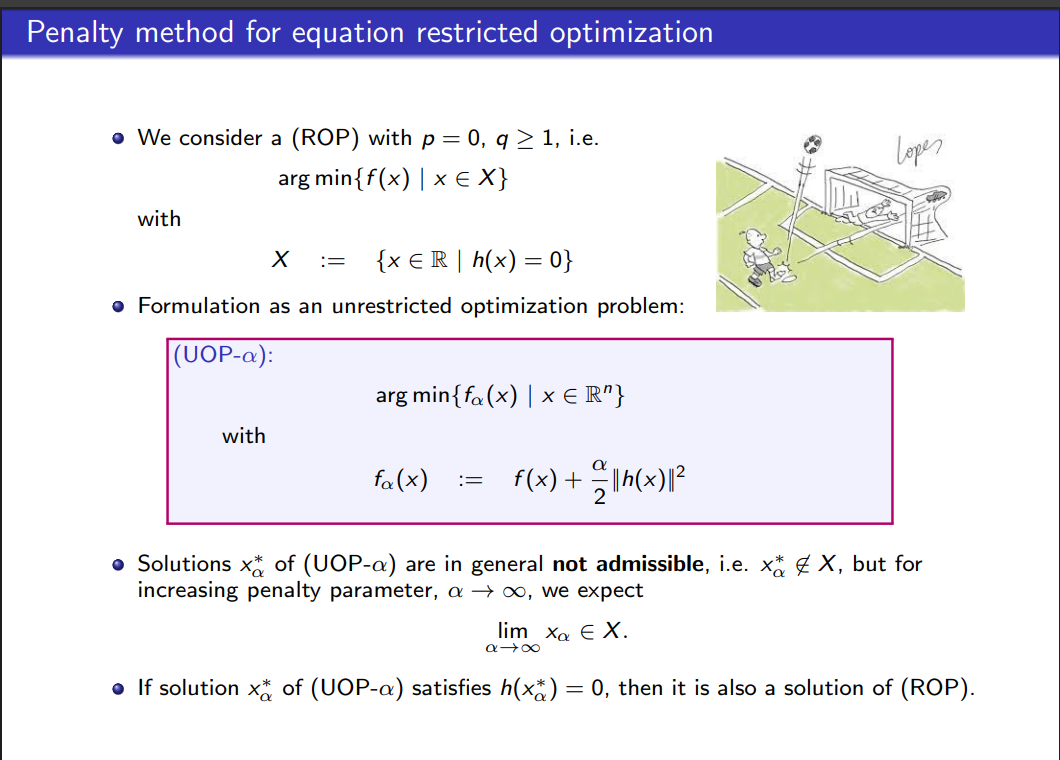

In [171]:
def penalty_method(c=0.2):
    print(f"\n---  Penalty Method for ROP (c={c}) ---")
    x = np.array([2,-1]) # Initial guess

    out=np.array([])
    for k in range(3,10):
        alpha_pen = 2**k

        # Define penalized objective and gradient closures
        def p_func(x_val):
            g_val = max(0.0, -x_val[0] + x_val[1] + c)
            return peano_f(x_val) + 0.5 * alpha_pen * g_val**2

        def grad_p_func(x_val):
            g_val = -x_val[0] + x_val[1] + c
            grad_g = np.array([-1.0, 1.0]) if g_val > 0 else np.array([0.0, 0.0])
            return peano_jac(x_val) + alpha_pen * max(0.0, g_val) * grad_g

        # Warm start using the x from the previous iteration
        x, iters = gradient_descent(x, p_func, grad_p_func, step_armijo)
        out = np.append(out,x)
        g_eval = -x[0] + x[1] + c
        is_admissible = g_eval <= 1e-6
        print(f"k={k}, alpha={alpha_pen:2d} | x: [{x[0]:.5f}, {x[1]:.5f}] | g(x): {g_eval: .5f} | Admissible: {is_admissible}")
    return out

restricted=penalty_method(c=1.0)


---  Penalty Method for ROP (c=1.0) ---
k=3, alpha= 8 | x: [2.40578, 2.45696] | g(x):  1.05117 | Admissible: False
k=4, alpha=16 | x: [1.59347, 0.89328] | g(x):  0.29981 | Admissible: False
k=5, alpha=32 | x: [1.20001, 0.32001] | g(x):  0.12000 | Admissible: False
k=6, alpha=64 | x: [1.07721, 0.13690] | g(x):  0.05969 | Admissible: False
k=7, alpha=128 | x: [1.03452, 0.06493] | g(x):  0.03040 | Admissible: False
k=8, alpha=256 | x: [1.01640, 0.03180] | g(x):  0.01540 | Admissible: False
k=9, alpha=512 | x: [1.00801, 0.01576] | g(x):  0.00775 | Admissible: False


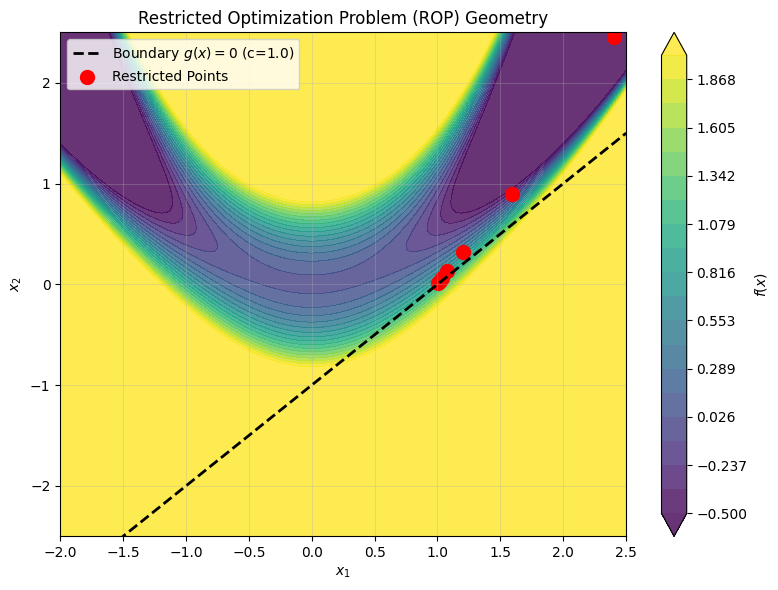

In [172]:
def plot_admissible_set(c=0.2):
    """
    Plots the Peano function contours and the admissible set X.
    """
    # Grid definition
    x1 = np.linspace(-2.0, 2.5, 400)
    x2 = np.linspace(-2.5, 2.5, 400)
    X1, X2 = np.meshgrid(x1, x2)

    # Peano function evaluation
    Z = (X1**2 - X2) * (X1**2 - 3.0 * X2)

    fig, ax = plt.subplots(figsize=(8, 6))

    # Contour plot of the objective function
    # Limiting the levels highlights the negative valley between the parabolas
    levels = np.linspace(-0.5, 2.0, 20)
    cp = ax.contourf(X1, X2, Z, levels=levels, cmap='viridis', extend='both', alpha=0.8)
    fig.colorbar(cp, ax=ax, label='$f(x)$')

    # Admissible set boundary: -x1 + x2 + c = 0 => x2 = x1 - c
    x2_boundary = x1 - c


    # Plot the constraint boundary line
    ax.plot(x1, x2_boundary, 'k--', linewidth=2, label=f'Boundary $g(x) = 0$ (c={c})')

    #points


    if restricted.size > 0:
        restricted_reshaped = restricted.reshape(-1, 2)
        ax.scatter(restricted_reshaped[:, 0], restricted_reshaped[:, 1], color='red', marker='o', s=100, label='Restricted Points')



    ax.set_xlim([-2.0, 2.5])
    ax.set_ylim([-2.5, 2.5])
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title('Restricted Optimization Problem (ROP) Geometry')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)


    plt.tight_layout()
    plt.show()

plot_admissible_set(c=1.0)